In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt 
import numpy as np 
import time 
import os
import sys
import pandas as pd 

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using {} device".format(device))

Using cuda device


In [3]:
#device='cpu'

The SDE is as follows: 
$$
\begin{align}
S_{n+1}&=S_n-4.0 \cdot 0.1 \cdot S_n(S^2_n-1)+\beta \sqrt{0.1} \omega_n \\ 
M_{n+1}&=S_{n+1} +\tau_{n+1}
\end{align}
$$

In [168]:
class Config(object):
    """
    F: Forcing
    n_dim: the dimension of the problem. 
    sigma_SDE: diffusion of the double well system. 
    dt: SDE system forward stepping size
    filter_steps: Perform filtering when every '' step 
    sigma_obs: the added noise of the observation process 
    
    """
    n_dim=1; 
    sigma_SDE=0.2;
    dt=torch.tensor(0.1); 
    filter_steps=200; 
    N=int(10.0/dt)
   
    ### EnSBF
    ensemble_size=400
    sigma_obs=torch.tensor(np.sqrt(0.1))

    ### Euler step constraints
    euler_steps=50
    dtt=torch.tensor(1.0/euler_steps)
    
def get_config(name):
    try:
        return globals()[name]
    except KeyError:
        raise KeyError("config not defined.")
        
cfg=get_config('Config')

In [169]:
class dynamic_sys(object): 
    def __init__(self,cfg):
        super (dynamic_sys,self).__init__()
        self.cfg=cfg; 
        self.rmse=[]
        self.state=[]
        self.obs=[]
        self.est=[]
        
        self.est_p=[]
        self.rmse_p=[]

        self.est_k=[]
        self.rmse_k=[]

        self.gamma=self.cfg.sigma_obs

        self.rng=np.random.randn
    #    self.scale=3.0
        
    def SB_Filter(self): 
        dt_np=self.cfg.dt.cpu().numpy();
        sigma_obs_np=cfg.sigma_obs.cpu().numpy();

        mlist=list(); 
        EXlist=list(); #The esemble particle list

        mlist_k=list(); 
        EXlist_k=list(); #The esemble kalman list

        
        x_target=-torch.ones(self.cfg.n_dim,device=device)  
        ## Guassian start
        x_state=-torch.ones(cfg.ensemble_size, self.cfg.n_dim, device=device)
        
        #############
        
        EX=torch.clone(x_state.squeeze()).cpu().numpy(); 
        self.est_p.append(-1)
        EXlist.append(EX)

        EX_k=torch.clone(x_state.squeeze()).cpu().numpy(); 
        self.est_k.append(-1)
        EXlist_k.append(EX_k)

        
        t_count=1.0
        for i in range(self.cfg.filter_steps): 
          # Find time 
            #print(f'step={i}:')
            #t1 = time.time()
            
        ### Prediction step
            #get the exact state
            x_target=x_target+self.cfg.dt*self.double_well(x_target) + np.sqrt(self.cfg.dt)*cfg.sigma_SDE*torch.randn_like(x_target)
            #get the one-step observational data. 
            y_state=x_target+torch.randn_like(x_target,device=device)*self.cfg.sigma_obs

            #get the prediction (algorithm)
            #given t-1|t-1, find the t|t-1
            
            ####################################  SBF
            x_state = x_state+self.cfg.dt*self.double_well(x_state) + np.sqrt(self.cfg.dt)*cfg.sigma_SDE*torch.randn_like(x_state)
            
            # transformation step: each of the particles in the x_state will be transformed to the target distribution
            # Based on t|t-1 and likelihood, find the t|t
            x_state=self.SB_forward(x_state,y_state)

            x_est=x_state.mean(axis=0)
            
            rmse_temp = torch.sqrt(torch.mean((x_est - x_target)**2)).item()
            
            #t2=time.time()
            #print(f'\t RMSE = {rmse_temp:.4f}')
            #print(f'\t time = {t2-t1:.4f} ')
            
            self.rmse.append(rmse_temp)
            self.state.append(x_target[0:10])
            self.obs.append(y_state[0:10])
            self.est.append(x_est)
            #######################################################################################

            ########################################### Particle ##################################
            Xhat=EXlist[-1]+dt_np*self.double_well(EXlist[-1]) + np.sqrt(dt_np)*cfg.sigma_SDE*self.rng(self.cfg.ensemble_size)
            dj=y_state.cpu().numpy()-Xhat ## inovation step
            gvec=np.exp(-0.5*dj**2/(self.gamma.cpu().numpy()**2)); 

            what=gvec/np.sum(gvec) 
            Fw=what.cumsum() # find the empirical cumulative function

            EX=self.resample(Xhat,Fw)

            self.est_p.append(EX.mean()); 
            EXlist.append(EX)
            rmse_temp_p=np.sqrt( (EX.mean() - x_target.cpu().numpy())**2 )
            self.rmse_p.append(rmse_temp_p)
            ##############################################################

            ######################################## Kalman Filter ###############################
            Xhat_k=EXlist_k[-1]+dt_np*self.double_well(EXlist_k[-1]) + np.sqrt(dt_np)*cfg.sigma_SDE*self.rng(self.cfg.ensemble_size)
            mhat_k=np.mean(Xhat_k); 
            Chat=np.sum((Xhat_k-mhat_k)**2)/(self.cfg.ensemble_size-1)

            Sj=Chat+self.gamma.cpu().numpy()
            Kj=Chat/Sj
            EY=y_state.cpu().numpy()+self.rng(self.cfg.ensemble_size)*self.gamma.cpu().numpy()
            EX_k=(1.0-Kj)*Xhat_k+Kj*EY

            mlist_k.append(EX.mean()); 
            EXlist_k.append(EX_k)
            #Xlist_k.append(Xj)
            rmse_temp_k=np.sqrt( (EX_k.mean() - x_target.cpu().numpy())**2 )
            self.est_k.append(EX_k.mean()); 
            self.rmse_k.append(rmse_temp_k)

            ######################################################################################
            ### Sign switch
            t_count+=1
            if t_count % 40 ==0:
                x_target=-x_target
            #print(t_count)
            
            if rmse_temp>=1000: 
                print('diverge!')
                break

    def ftVE(self,x1,a,x,y_obs,t): 
        ## alpha_0=0.0
        xVec=x.unsqueeze(1)
        p2= torch.sum((xVec-x1)**2,axis=2)
        args=torch.exp(torch.sum((x1-a)**2, axis=1)/(2.0)-p2/(2.0-2.0*t)-0.5*torch.sum((x1-y_obs)**2,axis=1)/(cfg.sigma_obs)**2)
        return args

    def uVE(self,X1,a,x,y_obs,t): 
        ## defining the numerator
        """
        x: a batch vector 
        y_state: observed state 
        """
        ## weights for each particle in a batch
        wts=self.ftVE(X1,a,x,y_obs,t)
        
        x_batch=-(x.unsqueeze(1)-X1)
        num1=x_batch*wts.unsqueeze(2)
        num=torch.mean(num1,axis=1) ## first axis is batch, second is ensemble size to be averaged out, third is dimension size  
        deno=torch.mean(wts,axis=1)*(1.0-t)
        uctrl=num/deno.unsqueeze(1)
        return uctrl 

    def SB_forward(self,X1,y_obs):
        ## we just want the terminal x1.
        ## a can be the [0,0] vector. 
        #Xt=a.clone()
        
        a = torch.mean(X1,axis=0)
        Xt=a.repeat(self.cfg.ensemble_size,1)  
        ### simulating the SDE trajectory by trajectory. 
        t=torch.tensor(0.0)
        for i in range(self.cfg.euler_steps): 
            Xt=Xt+self.cfg.dtt*self.uVE(X1,a,Xt,y_obs,t)+torch.randn_like(Xt)*torch.sqrt(self.cfg.dtt)
            t=t+self.cfg.dtt
        return Xt    
    
    def double_well(self, x): 
        res=-4.0*x*(x**2-1.0)
        return res

    def resample(self, ensX,FX):
        Xvec=list()
        for i in range(self.cfg.ensemble_size):
            idx=np.where(FX>=np.random.rand())[0][0]
            Xvec.append(ensX[idx]) 
        return np.array(Xvec)

In [170]:
lorenz=dynamic_sys(cfg)

In [171]:
lorenz.SB_Filter()
#lorenz.debug()

In [172]:
est_vec=torch.tensor(lorenz.est).cpu().numpy()

In [173]:
state_vec=torch.tensor(lorenz.state).cpu().numpy()

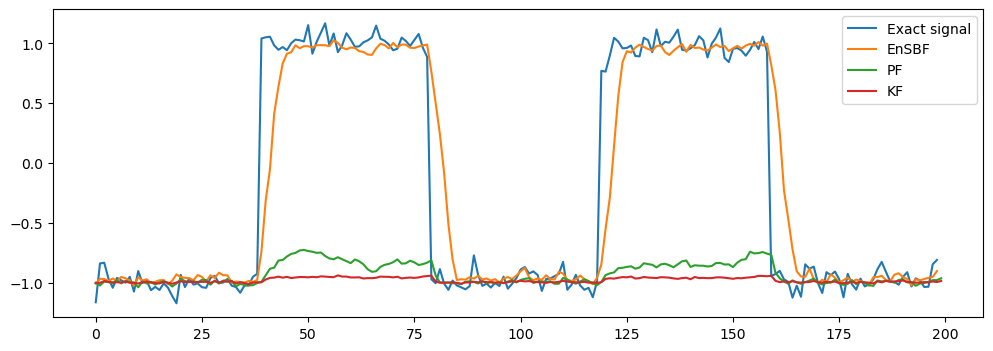

In [174]:
pnum=1
plt.figure(figsize=(12,4))
plt.plot(state_vec[:-pnum])
plt.plot(est_vec[:-pnum])
plt.plot(lorenz.est_p[:-pnum])
plt.plot(lorenz.est_k[:-pnum])
plt.legend(['Exact signal','EnSBF','PF','KF'])
#plt.savefig("potential_En1000Euler20_sig0.22.png")

In [175]:
rmse_v=np.array(lorenz.rmse)
rmse_v_p=np.array(lorenz.rmse_p)
rmse_v_k=np.array(lorenz.rmse_k)

In [176]:
vecs=np.arange(0.0, len(rmse_v),1)+1
smooth_err=rmse_v.cumsum()/vecs
smooth_err_p=rmse_v_p.cumsum()/vecs
smooth_err_k=rmse_v_k.cumsum()/vecs

Text(0.5, 1.0, 'Particle filter example')

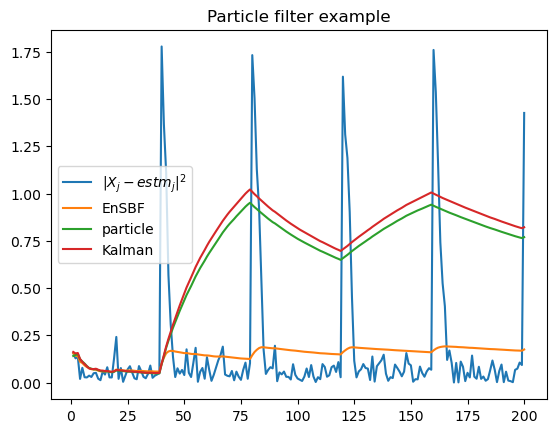

In [177]:
N0=0
NN=10000
plt.plot(vecs[N0:NN],rmse_v[N0:NN])
plt.plot(vecs[N0:NN],smooth_err[N0:NN])
plt.plot(vecs[N0:NN],smooth_err_p[N0:NN])
plt.plot(vecs[N0:NN],smooth_err_k[N0:NN])
plt.legend([r'$|X_j- est m_j|^2$','EnSBF', 'particle','Kalman'])
plt.title('Particle filter example')

## Conclusion is that 0.2 is a better example. 